In [48]:
!pip install langgraph

In [49]:
!pip install langchain

In [50]:
!pip install google-generativeai

In [51]:
!pip install langchain-google-genai

In [52]:
!pip install dotenv

In [53]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [54]:
load_dotenv()

True

In [55]:
model= ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)


In [56]:
class JokeState(TypedDict):

  topic:str
  joke:str
  explaination:str
  

In [57]:
def generate_joke(state:JokeState)->JokeState:

  prompt=f'write a joke on the topic {state["topic"]}'

  response=model.invoke(prompt).content

  return {'joke':response}

In [58]:
def generate_explanation(state:JokeState)->JokeState:

  prompt=f'write a explaination on the joke {state["joke"]}'

  response=model.invoke(prompt).content

  return {'explaination':response}


In [59]:
graph=StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer=InMemorySaver()

workflow=graph.compile(checkpointer=checkpointer)



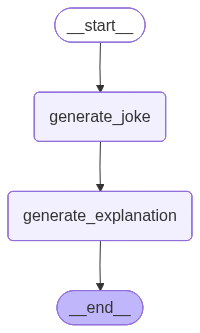

In [60]:
workflow

In [61]:
config1={"configurable":{"thread_id":"1"}}


workflow.invoke({'topic':'pizza'},config=config1)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 16.646943487s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job?\nBecause it needed more dough!', 'explaination': 'This joke is a classic example of a **pun**, which is a form of wordplay that exploits multiple meanings of a word, or words that sound similar but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Dough" (Meaning 1 - Literal):** When you think of pizza, "dough" immediately brings to mind the mixture of flour, water, and yeast that forms the base of the pizza. Pizzas are literally made from dough.\n\n2.  **"Dough" (Meaning 2 - Slang):** "Dough" is also a common slang term for **money**. If someone says they "need more dough," they mean they need more cash or income.\n\n**The Humor:**\n\nThe joke works by setting up an expectation related to the literal meaning of "dough" (the pizza ingredient) and then delivering a punchline that plays on the figurative, slang meaning (money).\n\n*   **Setup:** "Why did the pizza get a job?" - This makes you think a

In [ ]:
list(workflow.get_state_history(config1))

# intermediate state ka bhi de rha hai

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job?\nBecause it needed more dough!', 'explaination': 'This joke is a classic example of a **pun**, which is a form of wordplay that exploits multiple meanings of a word, or words that sound similar but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Dough" (Meaning 1 - Literal):** When you think of pizza, "dough" immediately brings to mind the mixture of flour, water, and yeast that forms the base of the pizza. Pizzas are literally made from dough.\n\n2.  **"Dough" (Meaning 2 - Slang):** "Dough" is also a common slang term for **money**. If someone says they "need more dough," they mean they need more cash or income.\n\n**The Humor:**\n\nThe joke works by setting up an expectation related to the literal meaning of "dough" (the pizza ingredient) and then delivering a punchline that plays on the figurative, slang meaning (money).\n\n*   **Setup:** "Why did the pizza get a job?" - This makes you think 

In [ ]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!',
 'explaination': 'This joke is a classic example of a **pun**!\n\nHere\'s the breakdown:\n\n1.  **The Setup:** "Why did the pasta get arrested?" This sets up an absurd scenario, as pasta is an inanimate food item and can\'t commit crimes. This immediately signals that the answer will likely be silly or wordplay-based.\n\n2.  **The Punchline:** "Because it was an **impasta**!"\n\n3.  **The Pun:** The word "impasta" sounds almost exactly like the word "**imposter**."\n    *   An **imposter** is a person who pretends to be someone else in order to deceive others, or someone who is not what they claim to be.\n    *   People who are imposters can indeed get arrested for fraud, impersonation, or other related crimes.\n\n4.  **The Humor:** The humor comes from:\n    *   **The unexpected twist:** You\'re expecting a logical (but impossible) reason for pasta to be arrested, but instead, you get a cl

In [ ]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!', 'explaination': 'This joke is a classic example of a **pun**!\n\nHere\'s the breakdown:\n\n1.  **The Setup:** "Why did the pasta get arrested?" This sets up an absurd scenario, as pasta is an inanimate food item and can\'t commit crimes. This immediately signals that the answer will likely be silly or wordplay-based.\n\n2.  **The Punchline:** "Because it was an **impasta**!"\n\n3.  **The Pun:** The word "impasta" sounds almost exactly like the word "**imposter**."\n    *   An **imposter** is a person who pretends to be someone else in order to deceive others, or someone who is not what they claim to be.\n    *   People who are imposters can indeed get arrested for fraud, impersonation, or other related crimes.\n\n4.  **The Humor:** The humor comes from:\n    *   **The unexpected twist:** You\'re expecting a logical (but impossible) reason for pasta to be arrested, but in

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!', 'explaination': 'This joke is a classic example of a **pun**!\n\nHere\'s the breakdown:\n\n1.  **The Setup:** "Why did the pasta get arrested?" This sets up an absurd scenario, as pasta is an inanimate food item and can\'t commit crimes. This immediately signals that the answer will likely be silly or wordplay-based.\n\n2.  **The Punchline:** "Because it was an **impasta**!"\n\n3.  **The Pun:** The word "impasta" sounds almost exactly like the word "**imposter**."\n    *   An **imposter** is a person who pretends to be someone else in order to deceive others, or someone who is not what they claim to be.\n    *   People who are imposters can indeed get arrested for fraud, impersonation, or other related crimes.\n\n4.  **The Humor:** The humor comes from:\n    *   **The unexpected twist:** You\'re expecting a logical (but impossible) reason for pasta to be arrested, but i

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job?\nBecause it needed more dough!', 'explaination': 'This joke is a classic example of a **pun**, which is a form of wordplay that exploits multiple meanings of a word, or words that sound similar but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Dough" (Meaning 1 - Literal):** When you think of pizza, "dough" immediately brings to mind the mixture of flour, water, and yeast that forms the base of the pizza. Pizzas are literally made from dough.\n\n2.  **"Dough" (Meaning 2 - Slang):** "Dough" is also a common slang term for **money**. If someone says they "need more dough," they mean they need more cash or income.\n\n**The Humor:**\n\nThe joke works by setting up an expectation related to the literal meaning of "dough" (the pizza ingredient) and then delivering a punchline that plays on the figurative, slang meaning (money).\n\n*   **Setup:** "Why did the pizza get a job?" - This makes you think 